LIBRERIAS
----


----

In [207]:
import pandas as pd
import numpy as np
import re
import pickle

In [208]:
from nltk.corpus import stopwords

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [210]:
from sklearn.preprocessing import LabelEncoder

In [211]:
import seaborn as sns
import matplotlib.pyplot as plt

DATOS
----


----

In [212]:
social_media = pd.read_csv('../data/raw/datos_social_media.csv')


In [213]:
social_media.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              10000 non-null  object 
 1   original_text     10000 non-null  object 
 2   url               10000 non-null  object 
 3   author_hash       6661 non-null   object 
 4   language          10000 non-null  object 
 5   primary_theme     9936 non-null   object 
 6   english_keywords  9853 non-null   object 
 7   sentiment         10000 non-null  float64
 8   main_emotion      10000 non-null  object 
 9   secondary_themes  10000 non-null  object 
dtypes: float64(1), object(9)
memory usage: 781.4+ KB


In [214]:
social_media = social_media.dropna()

In [215]:
social_media.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6597 entries, 0 to 9998
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              6597 non-null   object 
 1   original_text     6597 non-null   object 
 2   url               6597 non-null   object 
 3   author_hash       6597 non-null   object 
 4   language          6597 non-null   object 
 5   primary_theme     6597 non-null   object 
 6   english_keywords  6597 non-null   object 
 7   sentiment         6597 non-null   float64
 8   main_emotion      6597 non-null   object 
 9   secondary_themes  6597 non-null   object 
dtypes: float64(1), object(9)
memory usage: 566.9+ KB


In [216]:
social_media.describe()

,sentiment
count,6597.000000
mean,0.083327
std,0.428400
min,-0.940000
25%,-0.220000
50%,0.100000
75%,0.400000
max,0.970000


In [217]:
social_media.head(3)

,date,original_text,url,author_hash,language,primary_theme,english_keywords,sentiment,main_emotion,secondary_themes
0,2024-12-01T00:00:00.000Z,Ｑ:\n銀杏並木からラグビー場東門に通じる港区の区道の廃止手続きはいつを予定していますか？\...,https://x.com/L6K6REOaiF71115/status/186301012...,619fca2174ff02b246aae19903b1cf5d55be82b9,ja,Politics,"namiki, area, gate, east, harbor, framework, p...",-0.23,neutral,[ 3 11 7]
1,2024-12-01T00:00:00.000Z,Russian Defense Minister Andrey Belousov laid ...,https://x.com/RT_com/status/1863010120734568538,bc410c3cdef579aef084ee58828626a1c40e0e19,en,Politics,"dprk, soviet, belousov laid, defense, minister...",0.46,neutral,[ 3 11 7]
2,2024-12-01T00:00:00.000Z,Life isn't a choice it's a duty. \n@KindlyMyers,https://x.com/KindlyBfan/status/18630101211456...,2f77c6eabf92d58b777497c4fda819cbe411263d,en,Cryptocurrency,"isn, duty, life, choice, kindlymyers",-0.12,approval,[9 3 7]


In [218]:
social_media = social_media[social_media["date"].astype(str).str.startswith("2024")]

In [219]:
social_media = social_media.drop(columns=['url','author_hash']) 

In [220]:
social_media = social_media[social_media['language'] == 'en']

In [221]:
social_media.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4758 entries, 1 to 9998
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              4758 non-null   object 
 1   original_text     4758 non-null   object 
 2   language          4758 non-null   object 
 3   primary_theme     4758 non-null   object 
 4   english_keywords  4758 non-null   object 
 5   sentiment         4758 non-null   float64
 6   main_emotion      4758 non-null   object 
 7   secondary_themes  4758 non-null   object 
dtypes: float64(1), object(7)
memory usage: 334.5+ KB


NUMERICOS
----


----

In [222]:
theme = LabelEncoder()           
social_media['primary_theme_num'] = theme.fit_transform(social_media['primary_theme']) 

In [223]:
emotion = LabelEncoder()            
social_media['main_emotion_num'] = emotion.fit_transform(social_media['main_emotion']) 

In [224]:
social_media.columns

Index(['date', 'original_text', 'language', 'primary_theme',
       'english_keywords', 'sentiment', 'main_emotion', 'secondary_themes',
       'primary_theme_num', 'main_emotion_num'],
      dtype='object')

In [225]:
def map_sentiment(val):
    if val in [1, 2]:
        return "-1"
    elif val == 3:
        return "0"
    else:
        return "1"

social_media['sentiment_label'] = social_media['sentiment'].apply(map_sentiment)

In [226]:
social_media['sentiment_label'].value_counts()

sentiment_label
1    4758
Name: count, dtype: int64

In [227]:
def classify_sentiment_adjusted(score):
    if score > 0.01:      # Positivo si el score es mayor a 0.01
        return 'positive'
    elif score < -0.01:   # Negativo si el score es menor a -0.01
        return 'negative'
    else:
        return 'neutral'  # Neutral si está entre -0.01 y 0.01 (inclusive)

In [228]:
social_media['sentiment_label'] = social_media['sentiment'].apply(classify_sentiment_adjusted)
print(social_media['sentiment_label'].value_counts())

sentiment_label
positive    2654
negative    1971
neutral      133
Name: count, dtype: int64


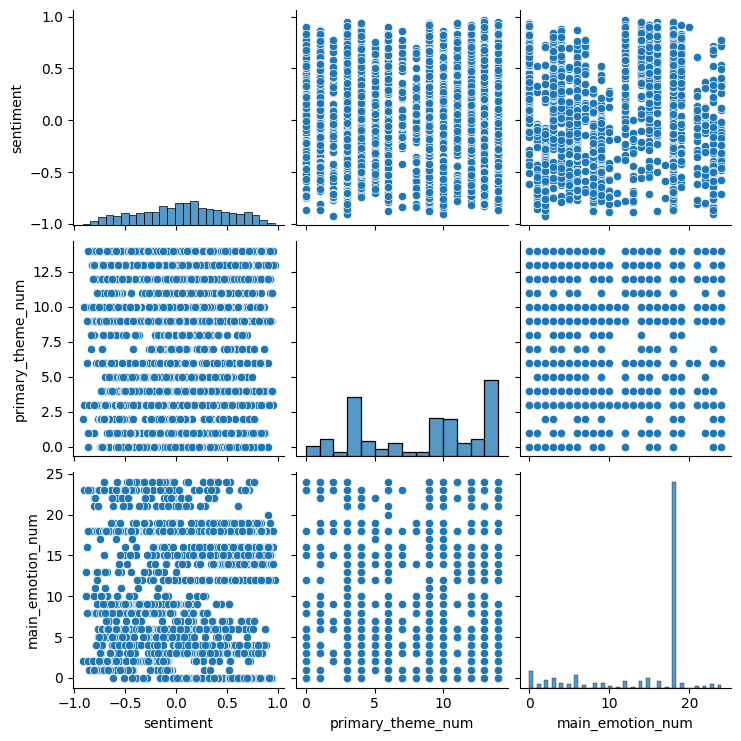

In [229]:
sns.pairplot(social_media);

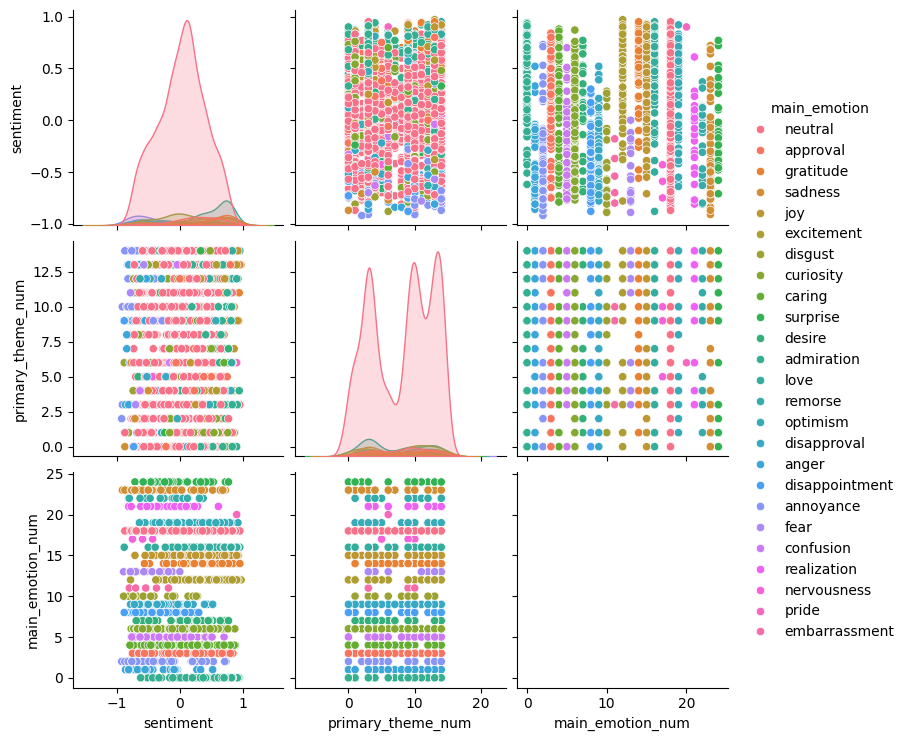

In [230]:
sns.pairplot(social_media,hue='main_emotion');

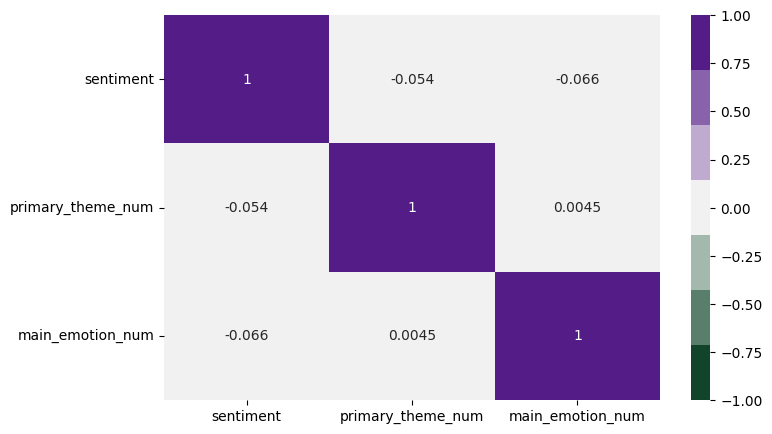

In [231]:
plt.figure(figsize=(8,5))
sns.heatmap(social_media.corr(numeric_only=True),
           vmin=-1,
           vmax=1,
           cmap=sns.diverging_palette(145, 280, s=85, l=25, n=7),
           annot=True);

DESCRIPCION
----


----

In [232]:
social_media['original_text'].head()

1     Russian Defense Minister Andrey Belousov laid ...
2      Life isn't a choice it's a duty.  \n@KindlyMyers
8     Here’s something to be thankful for on Thanksg...
9     Sandro Ramirez sent a message to Alejandro Bal...
10    As Sharon Osbourne sparks yet more surgery rum...
Name: original_text, dtype: object

In [233]:
import re
signos = re.compile(r"(\.)|(\;)|(\:)|(\!)|(\?)|(\¿)|(\@)|(\,)|(\")|(\()|(\))|(\[)|(\])|(\d+)|(//)|(-)|(\$)|(€)")

In [234]:
def signs_tweets(descripcion):
    return signos.sub('', descripcion.lower())

social_media['original_text_processed'] = social_media['original_text'].apply(signs_tweets)
social_media['original_text_processed'].head()

1     russian defense minister andrey belousov laid ...
2        life isn't a choice it's a duty  \nkindlymyers
8     here’s something to be thankful for on thanksg...
9     sandro ramirez sent a message to alejandro bal...
10    as sharon osbourne sparks yet more surgery rum...
Name: original_text_processed, dtype: object

In [235]:
def remove_links(social_media):
    return " ".join(['{link}' if ('http') in word else word for word in social_media.split()])

social_media['original_text_processed'] = social_media['original_text'].apply(remove_links)

In [236]:
import nltk

In [237]:
nltk.download('stopwords', download_dir='C:/Users/infoa/nltk_data')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:/Users/infoa/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [238]:
english_stopwords = stopwords.words('english')

In [239]:
def remove_stopwords(social_media):
    return " ".join([word for word in social_media.split() if word not in english_stopwords])

In [240]:
social_media['original_text_processed'] = social_media['original_text'].apply(remove_stopwords)
social_media.head()

,date,original_text,language,primary_theme,english_keywords,sentiment,main_emotion,secondary_themes,primary_theme_num,main_emotion_num,sentiment_label,original_text_processed
1,2024-12-01T00:00:00.000Z,Russian Defense Minister Andrey Belousov laid ...,en,Politics,"dprk, soviet, belousov laid, defense, minister...",0.46,neutral,[ 3 11 7],10,18,positive,Russian Defense Minister Andrey Belousov laid ...
2,2024-12-01T00:00:00.000Z,Life isn't a choice it's a duty. \n@KindlyMyers,en,Cryptocurrency,"isn, duty, life, choice, kindlymyers",-0.12,approval,[9 3 7],1,3,negative,Life choice duty. @KindlyMyers
8,2024-12-01T00:00:00.000Z,Here’s something to be thankful for on Thanksg...,en,Politics,"united, one, offices, local offices, and, fede...",0.86,gratitude,[ 3 11 7],10,14,positive,Here’s something thankful Thanksgiving weekend...
9,2024-12-01T00:00:00.000Z,Sandro Ramirez sent a message to Alejandro Bal...,en,Sports,"las palmas, alejandro balde, christmas, quick,...",-0.41,sadness,[8 1 7],13,23,negative,Sandro Ramirez sent message Alejandro Balde ap...
10,2024-12-01T00:00:00.000Z,As Sharon Osbourne sparks yet more surgery rum...,en,Health,"largest boom, facial, association, rhinoplasty...",0.60,neutral,[9 4 7],6,18,positive,"As Sharon Osbourne sparks yet surgery rumours,..."


In [241]:
from nltk.stem.snowball import SnowballStemmer

def english_stemmer(x):
    stemmer = SnowballStemmer('english')
    return " ".join([stemmer.stem(word) for word in x.split()])

social_media['original_text_processed'] = social_media['original_text'].apply(english_stemmer)
social_media['original_text_processed'].head()

1     russian defens minist andrey belousov laid flo...
2               life isn't a choic it a duty. @kindlymy
8     here someth to be thank for on thanksgiv weeke...
9     sandro ramirez sent a messag to alejandro bald...
10    as sharon osbourn spark yet more surgeri rumou...
Name: original_text_processed, dtype: object

In [242]:
social_media['original_text_processed'].head()

1     russian defens minist andrey belousov laid flo...
2               life isn't a choic it a duty. @kindlymy
8     here someth to be thank for on thanksgiv weeke...
9     sandro ramirez sent a messag to alejandro bald...
10    as sharon osbourn spark yet more surgeri rumou...
Name: original_text_processed, dtype: object

In [243]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#','', text)
    text = re.sub(r"\d+", '', text)
    text = re.sub(r'[^\w\s]', '', text)
    return text

In [244]:
social_media['original_text_processed'] = social_media['original_text_processed'].astype(str).apply(clean_text)

In [245]:
social_media.head(3)

,date,original_text,language,primary_theme,english_keywords,sentiment,main_emotion,secondary_themes,primary_theme_num,main_emotion_num,sentiment_label,original_text_processed
1,2024-12-01T00:00:00.000Z,Russian Defense Minister Andrey Belousov laid ...,en,Politics,"dprk, soviet, belousov laid, defense, minister...",0.46,neutral,[ 3 11 7],10,18,positive,russian defens minist andrey belousov laid flo...
2,2024-12-01T00:00:00.000Z,Life isn't a choice it's a duty. \n@KindlyMyers,en,Cryptocurrency,"isn, duty, life, choice, kindlymyers",-0.12,approval,[9 3 7],1,3,negative,life isnt a choic it a duty
8,2024-12-01T00:00:00.000Z,Here’s something to be thankful for on Thanksg...,en,Politics,"united, one, offices, local offices, and, fede...",0.86,gratitude,[ 3 11 7],10,14,positive,here someth to be thank for on thanksgiv weeke...


In [246]:
print(social_media['original_text_processed'].dtype)


object


In [247]:
social_media.columns

Index(['date', 'original_text', 'language', 'primary_theme',
       'english_keywords', 'sentiment', 'main_emotion', 'secondary_themes',
       'primary_theme_num', 'main_emotion_num', 'sentiment_label',
       'original_text_processed'],
      dtype='object')

Sentimientos en 3 clases:

COUNTVECTORIZER
----


----

In [248]:
X = social_media['original_text_processed']
y = social_media['sentiment_label']

In [249]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [250]:
print(X_train_vect.shape)
print(len(y_train))

(3806, 15378)
3806


In [251]:
corpus = social_media['original_text_processed']

In [ ]:
vectorizer = CountVectorizer(binary=True) #todo el texto
X = vectorizer.fit_transform(X)
vectorizer.get_feature_names_out()

array(['_____________________________', '__if', 'aaa', ..., '𝚝𝚎𝚕𝚕', '𝚝𝚘',
       '𝚝𝚛𝚢𝚒𝚗'], shape=(17564,), dtype=object)

In [253]:
len(vectorizer.get_feature_names_out())

17564

In [ ]:
texto_vectorizado = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out()) #todo el texto a 0
texto_vectorizado


,_____________________________,__if,aaa,aaaaaaaa,aaaand,aaiii,aamus,aapl,aav,ab,...,𝙏𝙪𝙣𝙚,𝙳𝚘𝚗𝚝,𝙸𝚖,𝚎𝚡𝚌𝚒𝚝𝚎𝚍,𝚐𝚎𝚝,𝚑𝚎𝚛𝚎,𝚓𝚞𝚜𝚝,𝚝𝚎𝚕𝚕,𝚝𝚘,𝚝𝚛𝚢𝚒𝚗
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4753,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4754,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4755,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4756,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [255]:
print(y_train.value_counts())
print(y_test.value_counts())

sentiment_label
positive    2123
negative    1577
neutral      106
Name: count, dtype: int64
sentiment_label
positive    531
negative    394
neutral      27
Name: count, dtype: int64


In [256]:
from sklearn.feature_extraction.text import CountVectorizer


In [ ]:
#texto_procesado_train = X_train
#texto_procesado_test = X_test

In [281]:
# Si aparece una palabra en el texto, le pone un 1. 
baseline_vectorizer = CountVectorizer(binary=True)
baseline_vectorizer.fit(X_train)

# Reviews en formato vector de palabras. El mismo vectorizador a test, tiene que mantener la estructura
X_baseline = baseline_vectorizer.transform(X_train)
X_test_baseline = baseline_vectorizer.transform(X_test)

In [259]:
X_baseline

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 92200 stored elements and shape (3806, 15309)>

In [260]:
print(X_baseline.shape)

# Asigna el numero
baseline_vectorizer.vocabulary_

(3806, 15309)


{'good': 5643,
 'counterfeit': 2965,
 'rolex': 11477,
 'still': 12808,
 'look': 7832,
 'nice': 9095,
 'doesnt': 3879,
 'make': 8036,
 'it': 6907,
 'the': 13441,
 'real': 10952,
 'thing': 13487,
 'switzerland': 13157,
 'players': 10241,
 'team': 13314,
 'season': 11851,
 'infonn': 6681,
 'not': 9291,
 'available': 914,
 'playerr': 10240,
 'cumul': 3181,
 'statisticsr': 12754,
 'rosterr': 11507,
 'first': 4968,
 'man': 8057,
 'to': 13632,
 'beat': 1156,
 'meat': 8268,
 'in': 6583,
 'decemb': 3384,
 'hello': 6091,
 'folks': 5094,
 'time': 13587,
 'nurtur': 9369,
 'our': 9670,
 'spirits': 12612,
 'add': 128,
 'your': 15156,
 'worri': 14979,
 'rosi': 11502,
 'cauldron': 2100,
 'and': 507,
 'brew': 1647,
 'some': 12463,
 'comfort': 2616,
 'share': 12047,
 'what': 14770,
 'on': 9525,
 'mind': 8492,
 'support': 13065,
 'each': 4094,
 'other': 9659,
 'cultivatedcoven': 3173,
 'bruh': 1719,
 'weight': 14720,
 'class': 2424,
 'for': 5116,
 'reason': 10970,
 'you': 15146,
 'can': 1946,
 'learn': 7

In [282]:
vectorizer_c = CountVectorizer()
vectorizer_c.fit(X_train)

#Cuenta las palabras
X_baseline_c = vectorizer_c.transform(X_train)

In [262]:
print(X_baseline_c.shape)
print(len(vectorizer_c.get_feature_names_out())) 

(3806, 15309)
15309


In [283]:
# Vectorizador binario (1 si la palabra aparece, 0 si no)
vectorizer = CountVectorizer(binary=True)

# Entrenar el vectorizador SOLO con el texto de entrenamiento
vectorizer.fit(X_train)

# Transformar train y test manteniendo la misma estructura
X_train_vect = vectorizer.transform(X_train)
X_test_vect = vectorizer.transform(X_test)

print("Train shape:", X_train_vect.shape)
print("Test shape:", X_test_vect.shape)

Train shape: (3806, 15309)
Test shape: (952, 15309)


In [284]:
train_model(X_train_vect, y_train, X_test_vect, y_test)

Final Accuracy: 0.7584033613445378


In [285]:
print(y_train.value_counts())
print(y_test.value_counts())

sentiment_label
positive    2123
negative    1577
neutral      106
Name: count, dtype: int64
sentiment_label
positive    531
negative    394
neutral      27
Name: count, dtype: int64


In [286]:
model = LogisticRegression(C=1)
model.fit(X_train_vect, y_train)

# Palabras más asociadas a sentimiento positivo
coef = model.coef_[0]
feature_names = vectorizer.get_feature_names_out()
sorted_features = sorted(zip(coef, feature_names), reverse=True)

print("Top palabras positivas:", sorted_features[:10])
print("Top palabras negativas:", sorted_features[-10:])

Top palabras positivas: [(np.float64(1.3538766848527173), 'fuck'), (np.float64(1.2796534889419893), 'hate'), (np.float64(1.2197705915246972), 'shit'), (np.float64(1.178368077729452), 'against'), (np.float64(1.1073276479020253), 'bad'), (np.float64(1.0142719748399067), 'wrong'), (np.float64(0.9779131992025559), 'evil'), (np.float64(0.9769957034439313), 'stop'), (np.float64(0.9565293257332864), 'stupid'), (np.float64(0.9308305897020499), 'question')]
Top palabras negativas: [(np.float64(-0.9048930008134078), 'thank'), (np.float64(-0.9687008310846716), 'super'), (np.float64(-0.972047449768573), 'benefit'), (np.float64(-0.9723828915343774), 'enjoy'), (np.float64(-0.9985364036772727), 'happi'), (np.float64(-1.0060398228672285), 'win'), (np.float64(-1.0313579323243571), 'love'), (np.float64(-1.0830462877686495), 'best'), (np.float64(-1.0871532783777804), 'good'), (np.float64(-1.158446545409887), 'better')]


In [288]:
social_media.head(5)

,date,original_text,language,primary_theme,english_keywords,sentiment,main_emotion,secondary_themes,primary_theme_num,main_emotion_num,sentiment_label,original_text_processed
1,2024-12-01T00:00:00.000Z,Russian Defense Minister Andrey Belousov laid ...,en,Politics,"dprk, soviet, belousov laid, defense, minister...",0.46,neutral,[ 3 11 7],10,18,positive,russian defens minist andrey belousov laid flo...
2,2024-12-01T00:00:00.000Z,Life isn't a choice it's a duty. \n@KindlyMyers,en,Cryptocurrency,"isn, duty, life, choice, kindlymyers",-0.12,approval,[9 3 7],1,3,negative,life isnt a choic it a duty
8,2024-12-01T00:00:00.000Z,Here’s something to be thankful for on Thanksg...,en,Politics,"united, one, offices, local offices, and, fede...",0.86,gratitude,[ 3 11 7],10,14,positive,here someth to be thank for on thanksgiv weeke...
9,2024-12-01T00:00:00.000Z,Sandro Ramirez sent a message to Alejandro Bal...,en,Sports,"las palmas, alejandro balde, christmas, quick,...",-0.41,sadness,[8 1 7],13,23,negative,sandro ramirez sent a messag to alejandro bald...
10,2024-12-01T00:00:00.000Z,As Sharon Osbourne sparks yet more surgery rum...,en,Health,"largest boom, facial, association, rhinoplasty...",0.60,neutral,[9 4 7],6,18,positive,as sharon osbourn spark yet more surgeri rumou...


In [ ]:
best_logistic_model = train_model(X_baseline, y_train, X_test_baseline, y_test)

Final Accuracy: 0.7584033613445378

¡El entrenamiento del modelo ha sido ejecutado!


In [267]:
print(y.value_counts())

sentiment_label
positive    2654
negative    1971
neutral      133
Name: count, dtype: int64


MODELOS
---

In [292]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [293]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_vect, y_train)

RandomForestClassifier(random_state=42)

In [294]:
y_pred_rf = rf_model.predict(X_test_vect)

# Mostrar métricas
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.7163865546218487

Classification Report:
               precision    recall  f1-score   support

    negative       0.70      0.61      0.65       394
     neutral       1.00      0.11      0.20        27
    positive       0.72      0.83      0.77       531

    accuracy                           0.72       952
   macro avg       0.81      0.52      0.54       952
weighted avg       0.72      0.72      0.71       952


Confusion Matrix:
 [[239   0 155]
 [ 10   3  14]
 [ 91   0 440]]


In [296]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, f1_score
import time

In [298]:
linear_svc_model = LinearSVC(max_iter=2000, random_state=42) # n_jobs=-1 no disponible para LinearSVC


In [299]:
linear_svc_model.fit(X_train_vectorized, y_train)

LinearSVC(max_iter=2000, random_state=42)

In [306]:
y_pred_svc = linear_svc_model.predict(X_test_vect)
accuracy_svc = accuracy_score(y_test, y_pred_svc)
f1_weighted_svc = f1_score(y_test, y_pred_svc, average='weighted')
f1_macro_svc = f1_score(y_test, y_pred_svc, average='macro')

In [307]:
print(f"Precisión (Linear SVC): {accuracy_svc:.4f}")
print(f"F1-Score Ponderado (Linear SVC): {f1_weighted_svc:.4f}")
print(f"F1-Score Macro (Linear SVC): {f1_macro_svc:.4f}")

Precisión (Linear SVC): 0.7458
F1-Score Ponderado (Linear SVC): 0.7383
F1-Score Macro (Linear SVC): 0.5594


In [310]:
from sklearn.neighbors import KNeighborsClassifier

In [319]:

knn_model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1) # Puedes experimentar con diferentes valores de n_neighbors


# Entrenar el modelo con las características vectorizadas
# ¡Asegúrate de que X_train_vectorized y y_train estén disponibles!
knn_model.fit(X_train_vectorized, y_train)



# Realizar predicciones
# ¡Asegúrate de que X_test_vectorized esté disponible!
y_pred_knn = knn_model.predict(X_test_vect)

# Evaluar el modelo
accuracy_knn = accuracy_score(y_test, y_pred_knn)
f1_weighted_knn = f1_score(y_test, y_pred_knn, average='weighted')
f1_macro_knn = f1_score(y_test, y_pred_knn, average='macro')

print(f"Precisión (K-Nearest Neighbors): {accuracy_knn:.4f}")
print(f"F1-Score Ponderado (K-Nearest Neighbors): {f1_weighted_knn:.4f}")
print(f"F1-Score Macro (K-Nearest Neighbors): {f1_macro_knn:.4f}")



Precisión (K-Nearest Neighbors): 0.5809
F1-Score Ponderado (K-Nearest Neighbors): 0.4770
F1-Score Macro (K-Nearest Neighbors): 0.3420


In [321]:
nombre_archivo = 'random_forest_model.pkl'

try:
    # Guardar el modelo entrenado en un archivo .pkl
    with open(nombre_archivo, 'wb') as archivo:
        pickle.dump(rf_model, archivo)
    print(f"Modelo Random Forest guardado exitosamente como '{nombre_archivo}'")
except Exception as e:
    print(f"Error al guardar el modelo Random Forest: {e}")

Modelo Random Forest guardado exitosamente como 'random_forest_model.pkl'
